In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import plotly.express as px
import statsmodels
from statsmodels.stats.diagnostic import lilliefors
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [38]:
df = pd.read_csv("housing.csv")

## Análise Gráficos

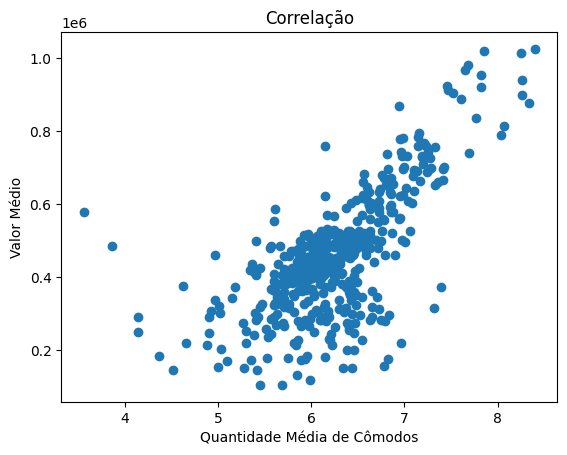

In [39]:
plt.scatter(df.RM, df.MEDV)
plt.title("Correlação")
plt.xlabel("Quantidade Média de Cômodos")
plt.ylabel("Valor Médio")
plt.grid(False)

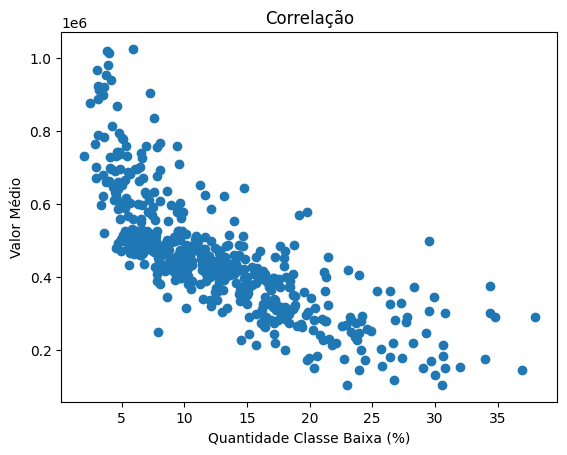

In [40]:
plt.scatter(df.LSTAT, df.MEDV)
plt.title("Correlação")
plt.xlabel("Quantidade Classe Baixa (%)")
plt.ylabel("Valor Médio")
plt.grid(False)

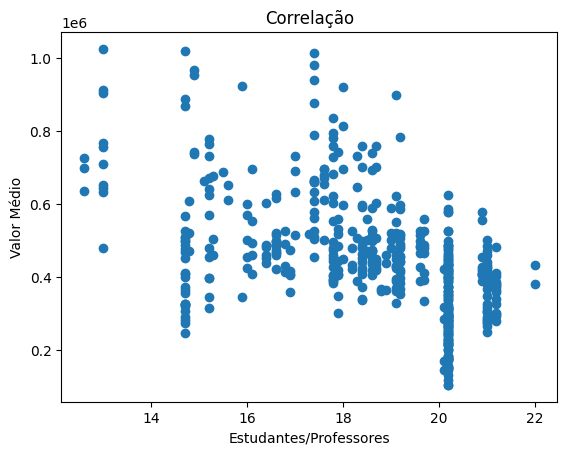

In [41]:
plt.scatter(df.PTRATIO, df.MEDV)
plt.title("Correlação")
plt.xlabel("Estudantes/Professores")
plt.ylabel("Valor Médio")
plt.grid(False)

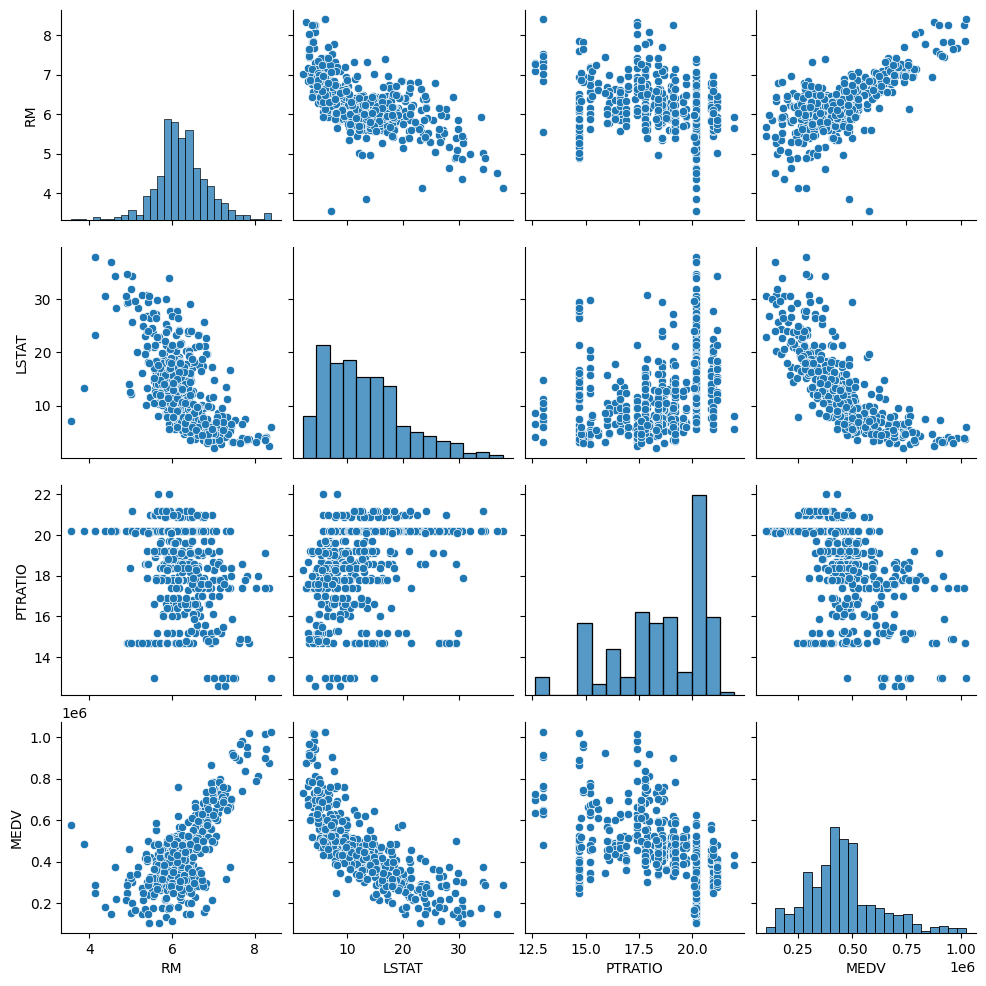

In [42]:
sns.pairplot(df)

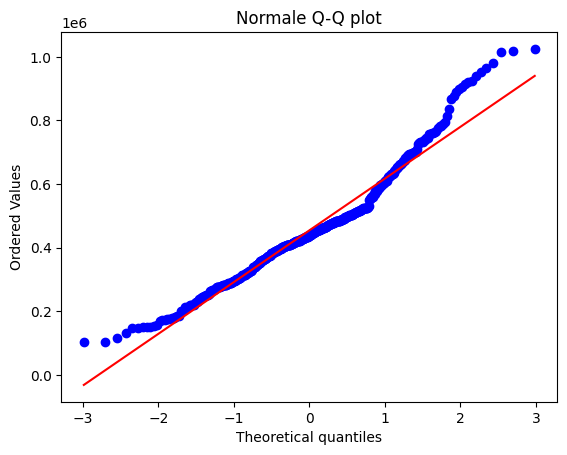

In [43]:
stats.probplot(df['MEDV'], dist="norm", plot=plt)
plt.title("Normale Q-Q plot")
plt.show()

In [44]:
hist = px.histogram(df, x="MEDV", nbins=60)
hist.update_layout(width=800, height=500, title_text="Média dos Valores")
hist.show()

## Testes de distribuição normal.

### Shapiro-Wilk. Utilizável para até 5000 registros.

Qualquer resposta com p_valor menor ou igual que 0.05 significa que não é uma distribuição normal

In [45]:
estatistica, p_valor = stats.shapiro(df.MEDV)
print("Estatistica do teste: {}".format(estatistica))
print("P-valor: {}".format(p_valor))

Estatistica do teste: 0.9596616055953767
P-valor: 2.5759801704018734e-10


In [46]:
estatistica, p_valor = stats.shapiro(df.RM)
print("Estatistica do teste: {}".format(estatistica))
print("P-valor: {}".format(p_valor))

Estatistica do teste: 0.9708170375303297
P-valor: 2.7090145811327798e-08


In [47]:
estatistica, p_valor = stats.shapiro(df.LSTAT)
print("Estatistica do teste: {}".format(estatistica))
print("P-valor: {}".format(p_valor))

Estatistica do teste: 0.9371757140975832
P-valor: 1.6898797071822296e-13


In [48]:
estatistica, p_valor = stats.shapiro(df.PTRATIO)
print("Estatistica do teste: {}".format(estatistica))
print("P-valor: {}".format(p_valor))

Estatistica do teste: 0.90647424903615
P-valor: 9.064596547331121e-17


### Lilliefors. Maior que 5000 registros

In [49]:
estatistica, p_valor = statsmodels.stats.diagnostic.lilliefors(df.MEDV, dist="norm")
print("Estatistica do teste: {}".format(estatistica))
print("P-valor: {}".format(p_valor))

Estatistica do teste: 0.11370576407672117
P-valor: 0.0009999999999998899


In [50]:
estatistica, p_valor = statsmodels.stats.diagnostic.lilliefors(df.RM, dist="norm")
print("Estatistica do teste: {}".format(estatistica))
print("P-valor: {}".format(p_valor))

Estatistica do teste: 0.06394344399233598
P-valor: 0.0009999999999998899


## Correlação Linear

Pearson (distribuição normal)\
Spearman (distribuição não normal)\
Kendall (distribuição não normal com quantidade pequena de amostras, menor que 30)

In [51]:
# Pearson
coef, p = stats.pearsonr(df.MEDV, df.RM)
print("Coeficiente de correlação: {}".format(coef))
print("p-valor: {}".format(p))

Coeficiente de correlação: 0.6972092210185156
p-valor: 2.0533141149514788e-72


In [52]:
# Spearman
coef, p = stats.spearmanr(df.MEDV, df.RM)
print("Coeficiente de correlação: {}".format(coef))
print("p-valor: {}".format(p))

Coeficiente de correlação: 0.6240572939087418
p-valor: 3.845028634343466e-54


In [53]:
# Kendall
coef, p = stats.kendalltau(df.MEDV, df.RM)
print("Coeficiente de correlação: {}".format(coef))
print("p-valor: {}".format(p))

Coeficiente de correlação: 0.4724931551110662
p-valor: 9.983146011545424e-55


In [54]:
correlacoes = df.corr(method="spearman")
correlacoes

,RM,LSTAT,PTRATIO,MEDV
RM,1.000000,-0.624700,-0.282053,0.624057
LSTAT,-0.624700,1.000000,0.461739,-0.845527
PTRATIO,-0.282053,0.461739,1.000000,-0.559276
MEDV,0.624057,-0.845527,-0.559276,1.000000


<Axes: >

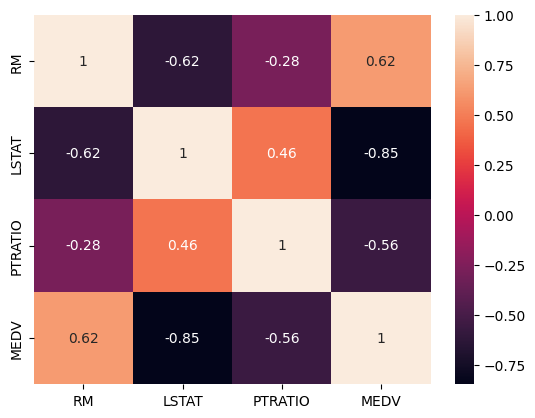

In [55]:
plt.figure()
sns.heatmap(correlacoes, annot=True )

## Regressão Linear Simples

### Valor Médio das casas em função da quantidade de cômodos

In [56]:
x1 = df.iloc[:, 0:1].values
y = df.iloc[:, 3].values
x_treino, x_teste, y_treino, y_teste = train_test_split(x1, y, test_size=0.3, random_state=0)

In [57]:
reg_linear1 = LinearRegression()
reg_linear1.fit(x_treino, y_treino)
reg_linear1.score(x_treino, y_treino)
previsoes_teste = reg_linear1.predict(x_teste)

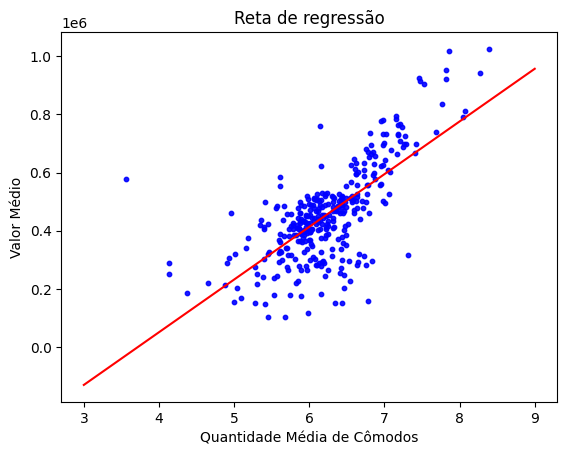

In [58]:
plt.scatter(y=y_treino, x=x_treino, color="blue", s=10, alpha=0.9)
X_plot = np.linspace(3, 9)
plt.plot(X_plot, X_plot*reg_linear1.coef_ + reg_linear1.intercept_, color='r')
plt.title("Reta de regressão")
plt.ylabel("Valor Médio")
plt.xlabel("Quantidade Média de Cômodos")
plt.show()

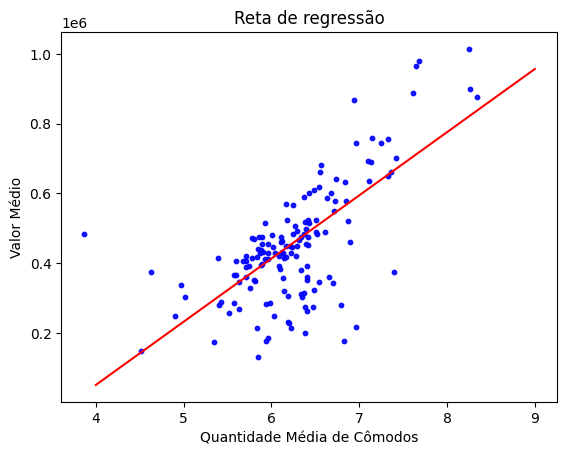

In [59]:
plt.scatter(y=y_teste, x=x_teste, color="blue", s=10, alpha=0.9)
X_plot = np.linspace(4, 9)
plt.plot(X_plot, X_plot*reg_linear1.coef_ + reg_linear1.intercept_, color='r')
plt.title("Reta de regressão")
plt.ylabel("Valor Médio")
plt.xlabel("Quantidade Média de Cômodos")
plt.show()

In [60]:
valor_casa = reg_linear1.predict([[4]])
valor_casa

array([51114.76179427])

In [61]:
abs(y_teste - previsoes_teste).mean()
mean_absolute_error(y_teste, previsoes_teste)
np.sqrt(mean_squared_error(y_teste, previsoes_teste))

np.float64(126207.31063140648)

In [62]:
kfold = KFold(n_splits=10, shuffle=True, random_state=0)
modelo = LinearRegression()
resultado = cross_validate(modelo, x_treino, y_treino, cv=kfold, scoring="r2", return_train_score=True)
print("R² Treino (Média):", resultado['train_score'].mean())
print("R² Validação (Média):", resultado['test_score'].mean())

R² Treino (Média): 0.5022258548685757
R² Validação (Média): 0.4122058716341589


### Valor Médio das casas em função da classe social

In [63]:
x2 = df.iloc[:, 1:2].values
y = df.iloc[:, 3].values
x_treino, x_teste, y_treino, y_teste = train_test_split(x2, y, test_size=0.3, random_state=0)

In [64]:
reg_linear2 = LinearRegression()
reg_linear2.fit(x_treino, y_treino)
reg_linear2.score(x_treino, y_treino)
previsoes_teste = reg_linear2.predict(x_teste)

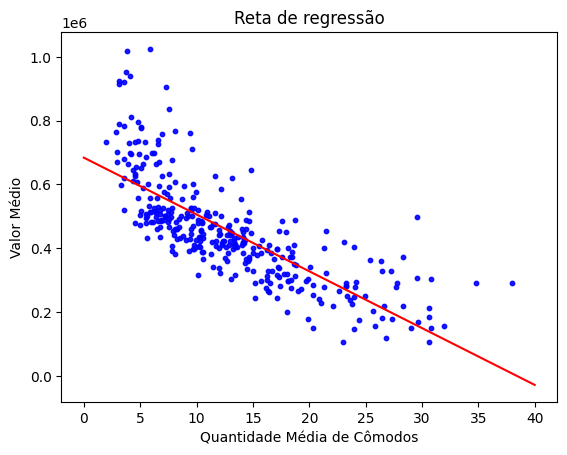

In [65]:
plt.scatter(y=y_treino, x=x_treino, color="blue", s=10, alpha=0.9)
X_plot = np.linspace(0, 40)
plt.plot(X_plot, X_plot*reg_linear2.coef_ + reg_linear2.intercept_, color='r')
plt.title("Reta de regressão")
plt.ylabel("Valor Médio")
plt.xlabel("Quantidade Média de Cômodos")
plt.show()

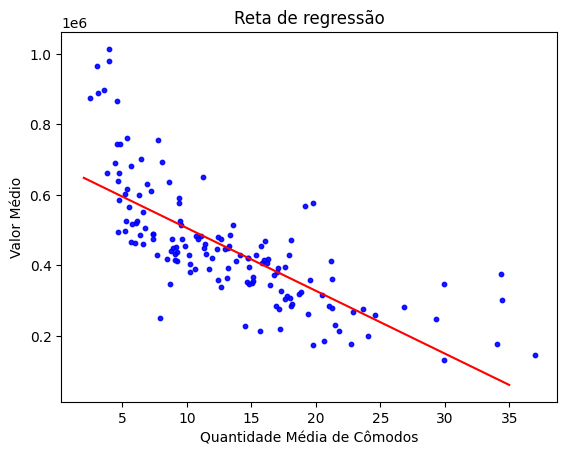

In [66]:
plt.scatter(y=y_teste, x=x_teste, color="blue", s=10, alpha=0.9)
X_plot = np.linspace(2, 35)
plt.plot(X_plot, X_plot*reg_linear2.coef_ + reg_linear2.intercept_, color='r')
plt.title("Reta de regressão")
plt.ylabel("Valor Médio")
plt.xlabel("Quantidade Média de Cômodos")
plt.show()

In [67]:
valor_casa = reg_linear2.predict([[10]])
valor_casa

array([506024.98179127])

In [68]:
abs(y_teste - previsoes_teste).mean()
mean_absolute_error(y_teste, previsoes_teste)
np.sqrt(mean_squared_error(y_teste, previsoes_teste))

np.float64(114877.3668217278)

In [69]:
kfold = KFold(n_splits=10, shuffle=True, random_state=0)
modelo = LinearRegression()
resultado = cross_validate(modelo, x_treino, y_treino, cv=kfold, scoring="r2", return_train_score=True)
print("R² Treino (Média):", resultado['train_score'].mean())
print("R² Validação (Média):", resultado['test_score'].mean())

R² Treino (Média): 0.5943429059628287
R² Validação (Média): 0.5649969708871663
